In [1]:
import pandas as pd
import numpy as np
import os
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import scipy.stats as stats
import arviz as az

sys.path.append(os.path.abspath('..'))
import utils
import mdp_utils
import process_data as dp
import bayesian_analysis as ba

%load_ext autoreload
%autoreload 2

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Failed to read module file 'C:\Python311\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311

In [2]:
state_features = ['TIR', 'TIME_Q', 'GOOD']
feature_names = ['Tiredness', 'Time available', 'Perceived Usefulness']

action_col = "joint_cluster"

cluster_col = 'cluster_all'
cluster_vars = ['likedness', 'usefulness', 'difficulty']
cluster_cols = [col + '_cluster' for col in cluster_vars]

reward_cols = ["r_likedness", "r_usefulness", "r_diversity", "r_expert", "r_return"]
obj_names = ["Fun", "Perceived Usefulness", "Diversity", "Difficulty-weighted Adherence", "Return Willingness"]

evaluation_cols = ["time_spent", "likedness", "usefulness", "PAY_next", "expert_score", "diversity"]
evaluation_names = ["Time Spent", "Likedness", "Perceived Usefulness", "Return Willingness", "Expert Usefulness", "Diversity"]

NUM_CATEGORIES = 4
NUM_FEATURES = len(state_features)
NUM_VALS_PER_FEATURE = [2, 2, 3]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 3
MAX_COUNT = 0
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CATEGORIES
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS * 2  # Within each cluster we either recommend a 'least favorite' coping category or a familiar one
NUM_OBJECTIVES = len(reward_cols)

In [3]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples.csv'))

actions_clustered, _, _ = dp.cluster_actions(action_data, cluster_vars, num_clusters=NUM_CLUSTERS)
# actions_clustered['cat_diff_cluster'] = actions_clustered.groupby(['category', 'expert_score']).ngroup()

df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, action_col, cluster_col, MAX_COUNT, NUM_CLUSTERS)
df.head(50)

Number of samples after processing: 3111


,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,TIR_next,MOT_next,GOOD_next,...,r_diversity,c_idx,s_idx,sp_idx,r_difficulty,r_likedness,r_usefulness,r_return,r_expert,joint_cluster
0,1111591584,1,5,6,6,3,6,4.0,4.0,5.0,...,1,0,8,1,0.000000,0.000000,0.000000,0.714286,0.00,5
1,1111591584,2,4,4,5,4,5,6.0,2.0,5.0,...,0,0,1,7,0.545455,0.909091,1.000000,0.857143,0.66,2
2,1111591584,3,6,2,5,3,6,4.0,5.0,5.0,...,0,0,7,4,0.454545,0.818182,0.714286,0.857143,1.00,1
3,1111591584,4,4,5,5,5,6,5.0,5.0,6.0,...,1,0,4,8,0.000000,0.000000,0.000000,0.857143,0.00,5
4,1111591584,5,5,5,6,4,6,3.0,4.0,6.0,...,0,0,8,2,0.363636,0.909091,1.000000,0.857143,0.66,1
5,1111591584,16,4,4,6,3,6,3.0,3.0,6.0,...,0,0,2,2,0.545455,0.818182,0.857143,0.857143,0.66,1
6,1139851159,1,4,5,5,4,4,2.0,7.0,6.0,...,0,0,1,5,0.818182,0.909091,1.142857,0.714286,0.33,1
7,1178274181,1,2,7,5,6,7,3.0,2.0,6.0,...,0,0,4,2,0.909091,0.636364,0.285714,1.000000,0.66,1
8,1178274181,2,3,2,6,2,7,5.0,1.0,4.0,...,0,0,2,9,0.272727,0.181818,0.285714,1.000000,0.66,2
9,1178274181,3,5,1,4,5,7,3.0,6.0,4.0,...,0,0,9,3,0.909091,0.727273,0.428571,1.000000,0.33,1


In [20]:
stochastic_outcomes = ["likedness", "usefulness", "difficulty", "PAY_next"]

for outcome in stochastic_outcomes:
    print(outcome + ": " + str(df[outcome].mean()) + " +- " + str(df[outcome].std()))

likedness: 4.311796849887496 +- 3.8241724429196724
usefulness: 3.133397621343619 +- 2.7039116589732215
difficulty: 2.568948891031823 +- 2.8273446840346157
PAY_next: 4.018322082931533 +- 1.5808292464774991


In [5]:
def evaluate_dynamics(test_df, P_comp, R, P, R_action_only, R_global, P_comp_action_only, p_comp_overall, R_outcomes, R_outcomes_action_only, R_probs_diff_global):
    data_list = []
    for t in range(len(test_df)):
        user_row = {"t": t}
        # True values
        s_t = test_df.iloc[t]['s_idx']
        c_t = test_df.iloc[t]['c_idx']
        a_t = test_df.iloc[t][action_col]
        s_t_next = test_df.iloc[t]['sp_idx']
        r_t = test_df.iloc[t][reward_cols].values
        completed = test_df.iloc[t]['completed']

        # Reward predictions
        r_pred = R[s_t, c_t, a_t]
        r_pred_action_only = R_action_only[a_t]
        r_pred_global = R_global
        
        for i, obj in enumerate(reward_cols):
            user_row[f'{obj}_l1_error'] = np.abs(r_t[i] - r_pred[i])
            user_row[f'{obj}_l1_error_action_only'] = np.abs(r_t[i] - r_pred_action_only[i])
            user_row[f'{obj}_l1_error_global'] = np.abs(r_t[i] - r_pred_global[i])
        # Next state likelihood
        P_s_t_next = P[s_t, a_t, s_t_next]
        user_row['next_state_likelihood'] = P_s_t_next
        user_row['equal_state'] = (s_t_next == s_t)
        user_row['s_idx'] = s_t
        user_row['s_idx_next'] = s_t_next

        # Completion likelihood
        P_comp_pred = P_comp[s_t, a_t]
        P_comp_pred_action_only = P_comp_action_only[a_t]
        user_row['completion_likelihood'] = P_comp_pred if completed else (1 - P_comp_pred)
        user_row['completion_likelihood_action_only'] = P_comp_pred_action_only if completed else (1 - P_comp_pred_action_only)
        user_row['completion_likelihood_overall'] = p_comp_overall if completed else (1 - p_comp_overall)
        user_row['completed'] = completed

        for outcome in stochastic_outcomes:
            outcome_value_t = test_df.iloc[t][outcome]
            if outcome == "PAY_next":
                outcome_value_t = outcome_value_t - 1  # convert 1-7 to 0-6 for indexing, for other outcomes the values are already 0-indexed, where 0 is equal to the non-completion probability
            if pd.isna(outcome_value_t):
                continue  # Skip if outcome value is missing
            R_outcome = R_outcomes[outcome]
            user_row[f'{outcome}_likelihood'] = R_outcome[s_t, a_t, int(outcome_value_t)]

            R_outcome_action_only = R_outcomes_action_only[outcome]
            outcome_likelihood_action_only = R_outcome_action_only[a_t, int(outcome_value_t)]
            user_row[f'{outcome}_likelihood_action_only'] = outcome_likelihood_action_only

            R_outcome_global = R_probs_diff_global[outcome]
            user_row[f'{outcome}_likelihood_global'] = R_outcome_global[int(outcome_value_t)]
        data_list.append(user_row)
        
    return pd.DataFrame(data_list)

In [6]:
all_users = df['user_id'].unique()
print("Number of users:", len(all_users))

lam = 1

all_user_results = []
for test_user in all_users:

    train_df = df[df['user_id'] != test_user]
    test_df = df[df['user_id'] == test_user]
    
    P_comp = mdp_utils.compute_completion_probabilities(train_df, NUM_USER_STATES, NUM_ACTIONS, action_col)
    R = mdp_utils.compute_rewards(train_df, P_comp, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, action_col, mapping)
    R_action_only = mdp_utils.compute_avg_rewards(train_df, NUM_ACTIONS, action_col, reward_cols)
    R_global = mdp_utils.compute_rewards_global(train_df, reward_cols)
    
    P = mdp_utils.compute_transition_probabilities(train_df, NUM_USER_STATES, NUM_ACTIONS, action_col, alpha=0)
    P_return = mdp_utils.compute_return_probabilities(train_df)
    
    P_comp_action_only = mdp_utils.compute_completion_probabilities_action_only(
        train_df, NUM_ACTIONS, action_col
    )

    p_comp_overall = train_df['completed'].mean()

    R_outcomes = {o: mdp_utils.compute_reward_probabilities(train_df, o, NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam) for o in stochastic_outcomes}

    R_outcomes_action_only = {o: mdp_utils.compute_reward_probabilities_action_only(train_df, o, NUM_ACTIONS, action_col, lam=lam) for o in stochastic_outcomes}
        
    R_probs_diff_global = {o: mdp_utils.compute_reward_probabilities_global(train_df, o) for o in stochastic_outcomes}
    
    result_df = evaluate_dynamics(test_df, P_comp, R, P, R_action_only, R_global, P_comp_action_only, p_comp_overall, 
                                  R_outcomes, R_outcomes_action_only, R_probs_diff_global)
    result_df['user_id'] = test_user
    all_user_results.append(result_df)
    
combined_results = pd.concat(all_user_results, ignore_index=True)

Number of users: 309


In [7]:
print("\nMean L1 errors by objective:")
l1_cols = [col + '_l1_error' for col in reward_cols]
print(combined_results[l1_cols].mean())

print("\nComparison of state-action vs action-only:")
for obj in reward_cols:
    sa_mean = combined_results[f'{obj}_l1_error'].mean()
    ao_mean = combined_results[f'{obj}_l1_error_action_only'].mean()
    print(f"{obj}: State-Action={sa_mean:.4f}, Action-Only={ao_mean:.4f}, Diff={sa_mean - ao_mean:.4f}")


Mean L1 errors by objective:
r_likedness_l1_error     0.259874
r_usefulness_l1_error    0.262810
r_diversity_l1_error     0.000000
r_expert_l1_error        0.276738
r_return_l1_error        0.165415
dtype: float64

Comparison of state-action vs action-only:
r_likedness: State-Action=0.2599, Action-Only=0.2623, Diff=-0.0024
r_usefulness: State-Action=0.2628, Action-Only=0.2645, Diff=-0.0016
r_diversity: State-Action=0.0000, Action-Only=0.0000, Diff=0.0000
r_expert: State-Action=0.2767, Action-Only=0.2743, Diff=0.0024
r_return: State-Action=0.1654, Action-Only=0.1728, Diff=-0.0074


### Reward function evaluation
To evaluate our learned reward function, we compare it against using only the action to predict the reward.

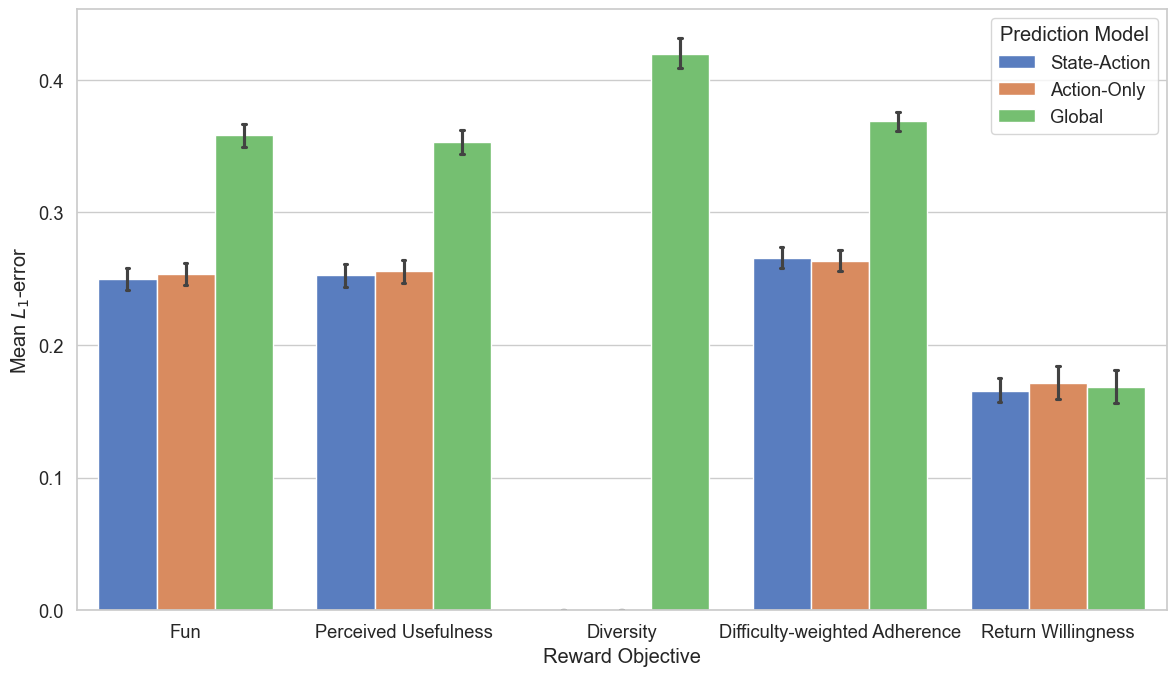

In [23]:
plot_records = []
for obj, obj_name in zip(reward_cols, obj_names):
    # if obj == "r_diversity":
    #     continue
    state_action = combined_results.groupby('user_id')[f'{obj}_l1_error'].mean()
    for err in state_action:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'State-Action'})
    
    action_only = combined_results.groupby('user_id')[f'{obj}_l1_error_action_only'].mean()
    for err in action_only:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'Action-Only'})

    global_errors = combined_results.groupby('user_id')[f'{obj}_l1_error_global'].mean()
    for err in global_errors:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'Global'})

viz_df = pd.DataFrame(plot_records)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)
ax = sns.barplot(
    data=viz_df, 
    x='Objective', 
    y='L1 Error', 
    hue='Model', 
    palette="muted",
    capsize=.05,
    errorbar=('ci', 95)
)

plt.ylabel('Mean $L_1$-error')
plt.xlabel('Reward Objective')
plt.legend(title='Prediction Model', frameon=True)

plt.savefig(results_folder + "figures/reward_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [9]:
for obj, obj_name in zip(reward_cols, obj_names):
    if obj == "r_diversity":
        continue  # Skip diversity for this analysis, since it is deterministic
    combined_results[f'{obj}_improvement'] = combined_results[f'{obj}_l1_error_action_only'] - combined_results[f'{obj}_l1_error']
    user_diffs = combined_results.groupby('user_id')[f'{obj}_improvement'].mean().values
    user_errs = combined_results.groupby('user_id')[f'{obj}_l1_error'].mean().values
    user_errs_action_only = combined_results.groupby('user_id')[f'{obj}_l1_error_action_only'].mean().values
    print(f"\n{obj_name}:")
    ba.paired_t_test(user_diffs)
    ba.two_sample_t_test(user_errs_action_only, user_errs)



Fun:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.003  0.001     0.001      0.006      0.000    0.000  4868.389   
effect_size  0.165  0.063     0.043      0.285      0.001    0.001  4429.419   

             ess_tail  r_hat  
improvement  3129.138  1.001  
effect_size  3007.747  1.001  
P(improvement > 0): 0.9962
P(Effect Size > 0.1): 0.8442
P(Effect Size > 0.2): 0.2920
P(Effect Size > 0.3): 0.0168
              mean     sd  hdi_2.5%  hdi_97.5%
improvement  0.004  0.006    -0.008      0.016
effect_size  0.050  0.085    -0.112      0.218
group1_mean  0.253  0.004     0.246      0.262
group2_mean  0.250  0.005     0.241      0.258
P(improvement > 0): 0.7170
P(Effect Size > 0.1): 0.3172
P(Effect Size > 0.2): 0.0405
P(Effect Size > 0.3): 0.0020

Perceived Usefulness:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.003  0.002    -0.000      0.006      0.000    0.000  4827.452   
effect_size  0

### Stochastic outcomes

C:\Users\shirl\AppData\Local\Temp\ipykernel_12552\170808968.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Fun', 'Perceived Usefulness', 'Return Willingness'])


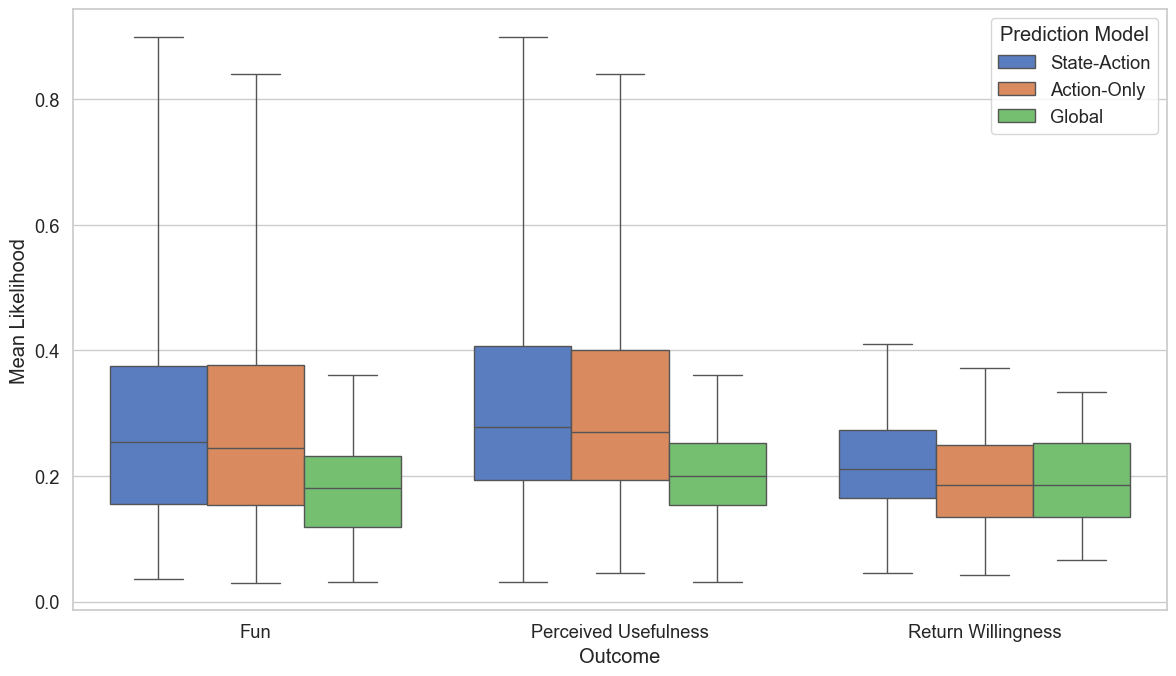

In [25]:
# plot mean likelihoods of outcomes
plot_records = []
for obj in stochastic_outcomes:
    if obj == "difficulty":
        continue
    state_action = combined_results.groupby('user_id')[f'{obj}_likelihood'].mean()
    for prob in state_action:
        plot_records.append({'Outcome': obj, 'Likelihood': prob, 'Model': 'State-Action'})
    
    action_only = combined_results.groupby('user_id')[f'{obj}_likelihood_action_only'].mean()
    for prob in action_only:
        plot_records.append({'Outcome': obj, 'Likelihood': prob, 'Model': 'Action-Only'})

    global_likelihoods = combined_results.groupby('user_id')[f'{obj}_likelihood_global'].mean()
    for prob in global_likelihoods:
        plot_records.append({'Outcome': obj, 'Likelihood': prob, 'Model': 'Global'})

viz_df = pd.DataFrame(plot_records)

# 2. Create the plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Use a barplot with 95% confidence intervals (black lines)
ax = sns.boxplot(
    data=viz_df, 
    x='Outcome', 
    y='Likelihood', 
    hue='Model', 
    palette='muted',
    whis=[0, 100]
    # capsize=.05,
    # errorbar=('ci', 95)
)
ax.set_xticklabels(['Fun', 'Perceived Usefulness', 'Return Willingness'])

# plt.title('Predictive Performance: State-Action vs. Action-Only Reward Models', fontsize=14)
plt.ylabel('Mean Likelihood')
plt.xlabel('Outcome')
plt.legend(title='Prediction Model', frameon=True)

plt.savefig(results_folder + "figures/outcome_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [11]:
for outcome in stochastic_outcomes:
    combined_results[f'{outcome}_improvement'] = combined_results[f'{outcome}_likelihood'] - combined_results[f'{outcome}_likelihood_action_only']
    user_diffs = combined_results.groupby('user_id')[f'{outcome}_improvement'].mean().values
    print(f"\n{outcome}:")
    ba.paired_t_test(user_diffs)


likedness:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.002  0.001     0.000      0.004      0.000    0.000  4769.127   
effect_size  0.156  0.069     0.016      0.289      0.001    0.001  4478.651   

             ess_tail  r_hat  
improvement  2955.961    1.0  
effect_size  2965.971    1.0  
P(improvement > 0): 0.9882
P(Effect Size > 0.1): 0.7957
P(Effect Size > 0.2): 0.2622
P(Effect Size > 0.3): 0.0192

usefulness:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.006  0.001     0.004      0.008      0.000    0.000  5286.704   
effect_size  0.316  0.068     0.188      0.452      0.001    0.001  3701.180   

             ess_tail  r_hat  
improvement  3215.072    1.0  
effect_size  3068.927    1.0  
P(improvement > 0): 1.0000
P(Effect Size > 0.1): 1.0000
P(Effect Size > 0.2): 0.9583
P(Effect Size > 0.3): 0.5833

difficulty:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd

### User state transition dynamics evaluation

,user_id,s_idx,next_state_likelihood,equal_state
0,1111591584,1,0.095238,0.0
1,1111591584,2,0.275362,1.0
2,1111591584,4,0.000000,0.0
3,1111591584,7,0.048780,0.0
4,1111591584,8,0.122222,0.0


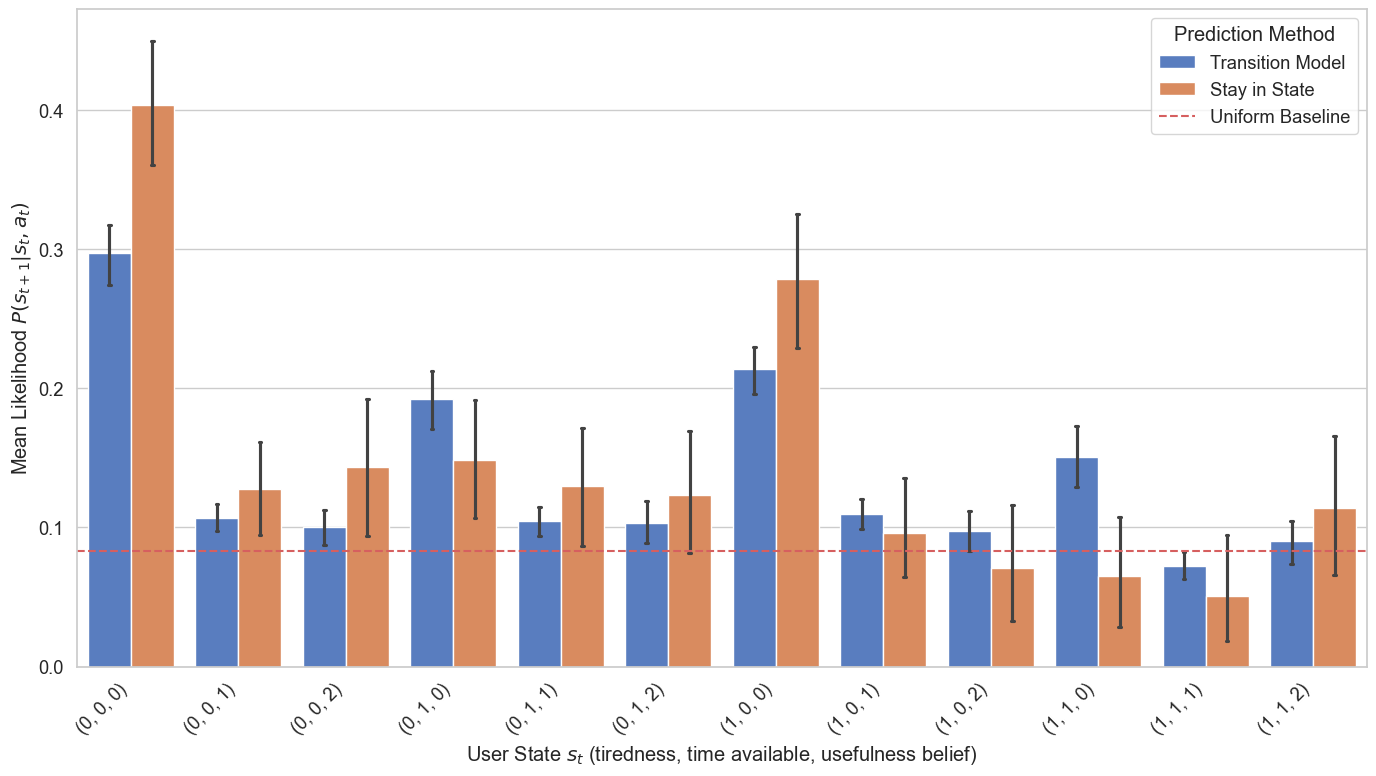

In [26]:
uniform_prob = 1.0 / NUM_USER_STATES

plot_data = combined_results.groupby(['user_id', 's_idx'])[['next_state_likelihood', 'equal_state']].mean().copy().reset_index()
display(plot_data.head())
plot_data['State'] = plot_data['s_idx'].apply(lambda x: str(utils.idx_to_user_state(x, NUM_VALS_PER_FEATURE)))

plot_data = plot_data.rename(columns={
    'next_state_likelihood': 'Transition Model',
    'equal_state': 'Stay in State'
})

# sort on s_idx to ensure states are in a logical order
plot_data = plot_data.sort_values('s_idx')

df_melted = plot_data.melt(id_vars=['State'], 
                           value_vars=['Transition Model', 'Stay in State'],
                           var_name='Model', 
                           value_name='Likelihood')



plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

ax = sns.barplot(
    data=df_melted, 
    x='State', 
    y='Likelihood', 
    hue='Model', 
    palette='muted',
    capsize=.05,
    errorbar=('ci', 95)
)

# plt.title('Next State Likelihood by User State', fontsize=16, pad=20)
plt.ylabel('Mean Likelihood $P(s_{t+1} | s_t, a_t)$')
plt.xlabel('User State $s_t$ (tiredness, time available, usefulness belief)')

plt.axhline(uniform_prob, color=sns.color_palette("muted")[3], linestyle='--', alpha=1, label='Uniform Baseline')
plt.xticks(rotation=45, ha='right')

plt.legend(title='Prediction Method')
plt.savefig(results_folder + "figures/transition_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [13]:
combined_results['next_state_improvement'] = combined_results['next_state_likelihood'] - combined_results['equal_state']
user_diffs_per_state = combined_results.groupby(['user_id', 's_idx'])['next_state_improvement'].mean().values

for state_idx in range(NUM_USER_STATES):
    state_diffs = combined_results[combined_results['s_idx'] == state_idx].groupby('user_id')['next_state_improvement'].mean().values
    print(f"\nState {state_idx} ({utils.idx_to_user_state(state_idx, NUM_VALS_PER_FEATURE)}):")
    ba.paired_t_test(state_diffs)


State 0 ((0, 0, 0)):
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement -0.107  0.014    -0.136     -0.081      0.000    0.000  3915.596   
effect_size -0.543  0.076    -0.690     -0.393      0.001    0.001  3936.082   

             ess_tail  r_hat  
improvement  2900.928  1.001  
effect_size  3249.599  1.001  
P(improvement > 0): 0.0000
P(Effect Size > 0.1): 1.0000
P(Effect Size > 0.2): 1.0000
P(Effect Size > 0.3): 0.9995

State 1 ((0, 0, 1)):
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.064  0.008     0.048      0.081      0.000    0.000  1665.613   
effect_size  0.987  0.227     0.556      1.459      0.007    0.007  1231.718   

             ess_tail  r_hat  
improvement  1177.384  1.001  
effect_size   813.311  1.003  
P(improvement > 0): 1.0000
P(Effect Size > 0.1): 0.9998
P(Effect Size > 0.2): 0.9982
P(Effect Size > 0.3): 0.9958

State 2 ((0, 0, 2)):
              mean     sd  hdi_2.5%  h

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.034  0.030    -0.034      0.079      0.002    0.001   513.662   
effect_size  0.411  0.336    -0.223      1.019      0.020    0.007   314.246   

             ess_tail  r_hat  
improvement   710.039  1.015  
effect_size   793.771  1.020  
P(improvement > 0): 0.8535
P(Effect Size > 0.1): 0.8682
P(Effect Size > 0.2): 0.7550
P(Effect Size > 0.3): 0.6595


In [14]:
user_diffs = combined_results.groupby('user_id')['next_state_improvement'].mean().values
print("\nOverall Next State Prediction Improvement:")
ba.paired_t_test(user_diffs)


Overall Next State Prediction Improvement:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement -0.111  0.009    -0.130     -0.093      0.000    0.000  2151.589   
effect_size -0.771  0.070    -0.923     -0.645      0.001    0.001  2946.549   

             ess_tail  r_hat  
improvement  2628.846  1.002  
effect_size  2353.147  1.002  
P(improvement > 0): 0.0000
P(Effect Size > 0.1): 1.0000
P(Effect Size > 0.2): 1.0000
P(Effect Size > 0.3): 1.0000


### Completion probabilities evaluation

C:\Users\shirl\AppData\Local\Temp\ipykernel_12552\269453204.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


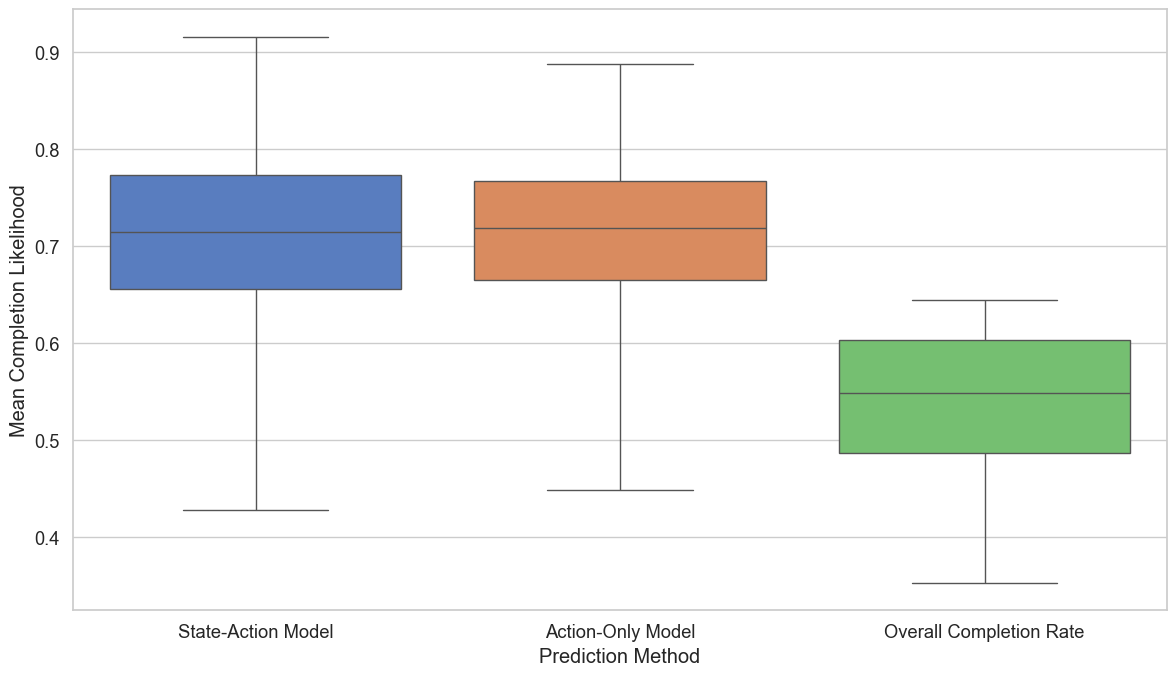


Mean completion likelihoods:
State-Action Model: 0.7167
  95% HDI: [0.0869, 0.9159]
Action-Only Model: 0.7146
  95% HDI: [0.1871, 0.8899]
Overall Completion Rate: 0.5400
  95% HDI: [0.3535, 0.6461]


In [27]:
plot_records = []
model_map = {
    'completion_likelihood': 'State-Action Model',
    'completion_likelihood_action_only': 'Action-Only Model',
    'completion_likelihood_overall': 'Overall Completion Rate'
}

for col, model_name in model_map.items():
    for _, row in combined_results.groupby('user_id').mean().iterrows():
        plot_records.append({
            'Model': model_name,
            'Likelihood': row[col],
            'Completed': 'Completed' if row['completed'] == 1 else 'Not Completed'
            
        })

plot_df = pd.DataFrame(plot_records)


plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

ax = sns.boxplot(
    data=plot_df, 
    x='Model', 
    y='Likelihood', 
    palette='muted',
    whis=[0, 100]
    # capsize=.05,
    # errorbar=('ci', 95)
)

# sns.stripplot(plot_df, x='Model', y='Likelihood', hue='Model', alpha=0.5)

# plt.title('Completion Likelihood by Prediction Model', fontsize=14)
plt.ylabel('Mean Completion Likelihood')
plt.xlabel('Prediction Method')
plt.savefig(results_folder + "figures/completion_likelihood_comparison.svg", bbox_inches='tight')

plt.tight_layout()
plt.show()

print("\nMean completion likelihoods:")
for col, model_name in model_map.items():
    mean_likelihood = combined_results.groupby('user_id')[col].mean().mean()
    print(f"{model_name}: {mean_likelihood:.4f}")
    hdi = az.hdi(np.array(combined_results[col]), hdi_prob=0.95)   
    print(f"  95% HDI: [{hdi[0]:.4f}, {hdi[1]:.4f}]")

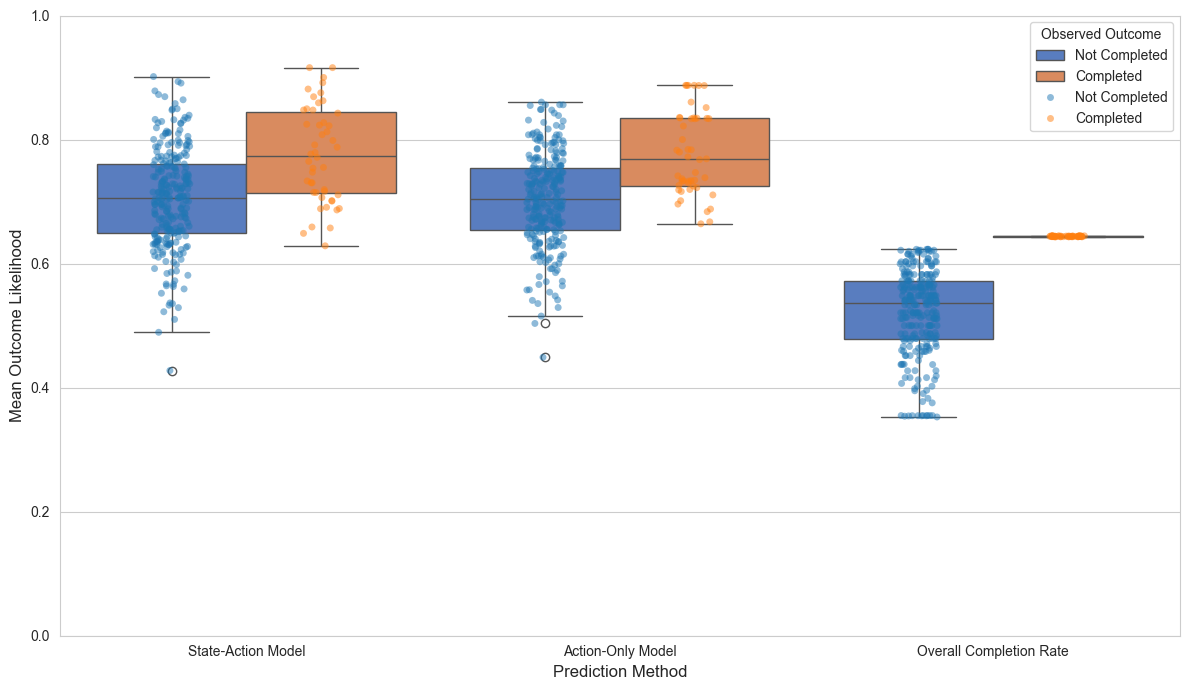

In [16]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=plot_df,
    x='Model',
    y='Likelihood',
    hue='Completed',
    palette='muted'
)

sns.stripplot(
    data=plot_df,
    x='Model',
    y='Likelihood',
    hue='Completed',
    dodge=True,
    alpha=0.5,
    jitter=True
)

# plt.title('Completion Probability Distributions by Outcome', fontsize=14)

plt.ylabel('Mean Outcome Likelihood', fontsize=12)
plt.xlabel('Prediction Method', fontsize=12)

plt.ylim(0, 1)

plt.legend(title='Observed Outcome')
plt.savefig(results_folder + "figures/completion_likelihood_distributions.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [17]:
combined_results['completion_likelihood_diff'] = combined_results['completion_likelihood'] - combined_results['completion_likelihood_action_only']
user_diffs = combined_results.groupby('user_id')['completion_likelihood_diff'].mean().values
ba.paired_t_test(user_diffs)

              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.001  0.001    -0.002      0.004      0.000    0.000  4604.074   
effect_size  0.049  0.063    -0.073      0.172      0.001    0.001  4807.966   

             ess_tail  r_hat  
improvement  3066.363    1.0  
effect_size  3141.278    1.0  
P(improvement > 0): 0.7778
P(Effect Size > 0.1): 0.2170
P(Effect Size > 0.2): 0.0088
P(Effect Size > 0.3): 0.0000
